In [55]:
import torch 
import numpy as np
import matplotlib.pyplot as plt

In [56]:
import torch.nn as nn
class PNN(torch.nn.Module):
    def __init__(self):
        super(PNN, self).__init__()
        self.lb = torch.tensor([-1.0, 0.0])
        self.ub = torch.tensor([1.0, 1.0])
       
        self.network=torch.nn.Sequential(
            nn.Linear(2,50),
            nn.Tanh(),
            nn.Linear(50,50),
            nn.Tanh(),
            nn.Linear(50,50),
            nn.Tanh(),
            nn.Linear(50,2)
        )

    def forward(self, x, t):
        X = torch.cat([x, t], dim=1)
        out=self.network(X)
        u = out[:,0:1]
        v = out[:,1:2]
        return u, v

In [57]:
model = PNN()

In [58]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [59]:
xmin = -5.0
xmax = 5.0

tmin = 0.0
tmax = torch.pi / 2

In [61]:
N_ic = 200

x_ic = torch.rand(N_ic,1)*(xmax-xmin)+xmin

t_ic = torch.zeros_like(x_ic)

In [62]:
u_ic = 2.0 / torch.cosh(x_ic)

v_ic = torch.zeros_like(x_ic)

In [63]:
N_bc = 200

t_bc = (torch.rand(N_bc,1)*(tmax-tmin)).requires_grad_(True)

x_left = torch.full((N_bc,1), xmin, requires_grad=True)
x_right = torch.full((N_bc,1), xmax, requires_grad=True)

In [64]:
u_left,v_left = model(x_left,t_bc)

u_right,v_right = model(x_right,t_bc)

In [65]:
N_f = 10000

x_f = (torch.rand(N_f,1)*(xmax-xmin)+xmin).requires_grad_(True)

t_f = (torch.rand(N_f,1)*(tmax-tmin)).requires_grad_(True)

In [66]:
def physics_residual(model, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u, v = model(x, t)
    u_x = torch.autograd.grad(
        outputs=u,
        inputs=x,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
    )[0]
    u_t = torch.autograd.grad(
        outputs=u,
        inputs=t,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
    )[0]
    u_xx = torch.autograd.grad(
        outputs=u_x,
        inputs=x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
    )[0]
    v_t = torch.autograd.grad(
    v,
    t,
    grad_outputs=torch.ones_like(v),
    create_graph=True
     )[0]

    v_x = torch.autograd.grad(
    v,
    x,
    grad_outputs=torch.ones_like(v),
    create_graph=True
    )[0]

    v_xx = torch.autograd.grad(
    v_x,
    x,
    grad_outputs=torch.ones_like(v_x),
    create_graph=True
    )[0]
    
    modulus = u**2 + v**2

    f_u = -v_t + 0.5*u_xx + modulus*u

    f_v = u_t + 0.5*v_xx + modulus*v
    return f_u, f_v

In [67]:
epochs = 5000

for epoch in range(epochs):

    optimizer.zero_grad()

    # -------------------------
    # Initial Condition Loss
    # -------------------------
    u_ic_pred, v_ic_pred = model(x_ic, t_ic)

    loss_ic = torch.mean((u_ic_pred - u_ic) ** 2)
    loss_ic += torch.mean((v_ic_pred - v_ic) ** 2)

    # -------------------------
    # Boundary Condition Loss
    # -------------------------
    u_left_pred, v_left_pred = model(x_left, t_bc)
    u_right_pred, v_right_pred = model(x_right, t_bc)

    # Periodic values
    loss_bc = torch.mean((u_left_pred - u_right_pred) ** 2)
    loss_bc += torch.mean((v_left_pred - v_right_pred) ** 2)

    # First derivatives
    ux_left = torch.autograd.grad(
        outputs=u_left_pred,
        inputs=x_left,
        grad_outputs=torch.ones_like(u_left_pred),
        create_graph=True,
    )[0]

    ux_right = torch.autograd.grad(
        outputs=u_right_pred,
        inputs=x_right,
        grad_outputs=torch.ones_like(u_right_pred),
        create_graph=True,
    )[0]

    vx_left = torch.autograd.grad(
        outputs=v_left_pred,
        inputs=x_left,
        grad_outputs=torch.ones_like(v_left_pred),
        create_graph=True,
    )[0]

    vx_right = torch.autograd.grad(
        outputs=v_right_pred,
        inputs=x_right,
        grad_outputs=torch.ones_like(v_right_pred),
        create_graph=True,
    )[0]

    # Periodic derivative loss
    loss_bc += torch.mean((ux_left - ux_right) ** 2)
    loss_bc += torch.mean((vx_left - vx_right) ** 2)

    # -------------------------
    # Physics Loss
    # -------------------------
    f_u, f_v = physics_residual(model, x_f, t_f)

    loss_pde = torch.mean(f_u ** 2)
    loss_pde += torch.mean(f_v ** 2)

    # -------------------------
    # Total Loss
    # -------------------------
    total_loss = loss_ic + loss_bc + loss_pde

    total_loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Total={total_loss.item():.6f} | "
            f"IC={loss_ic.item():.6f} | "
            f"BC={loss_bc.item():.6f} | "
            f"PDE={loss_pde.item():.6f}"
        )

Epoch     0 | Total=1.392461 | IC=0.887650 | BC=0.503157 | PDE=0.001653
Epoch   100 | Total=0.132347 | IC=0.084080 | BC=0.003763 | PDE=0.044505
Epoch   200 | Total=0.098929 | IC=0.061800 | BC=0.001977 | PDE=0.035152
Epoch   300 | Total=0.069587 | IC=0.038549 | BC=0.000827 | PDE=0.030211
Epoch   400 | Total=0.062272 | IC=0.032971 | BC=0.000237 | PDE=0.029064
Epoch   500 | Total=0.060852 | IC=0.030366 | BC=0.002108 | PDE=0.028377
Epoch   600 | Total=0.055316 | IC=0.027824 | BC=0.000116 | PDE=0.027376
Epoch   700 | Total=0.052780 | IC=0.026034 | BC=0.000099 | PDE=0.026647
Epoch   800 | Total=0.051806 | IC=0.024990 | BC=0.000963 | PDE=0.025853
Epoch   900 | Total=0.049028 | IC=0.023649 | BC=0.000105 | PDE=0.025273
Epoch  1000 | Total=0.047456 | IC=0.022693 | BC=0.000136 | PDE=0.024628
Epoch  1100 | Total=0.045974 | IC=0.021792 | BC=0.000094 | PDE=0.024088
Epoch  1200 | Total=0.044623 | IC=0.021059 | BC=0.000098 | PDE=0.023467
Epoch  1300 | Total=0.043270 | IC=0.020212 | BC=0.000108 | PDE=0

In [68]:
Nx = 256
Nt = 100

x = torch.linspace(xmin, xmax, Nx).view(-1, 1)
t = torch.linspace(tmin, tmax, Nt).view(-1, 1)

X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing="ij")

x_test = X.reshape(-1, 1)
t_test = T.reshape(-1, 1)

In [69]:
model.eval()

with torch.no_grad():
    u_pred, v_pred = model(x_test, t_test)

In [70]:
h = torch.sqrt(u_pred**2 + v_pred**2)

In [71]:
h.shape

(25600,1)

(25600, 1)

In [72]:
H = h.reshape(Nx, Nt).cpu().numpy()

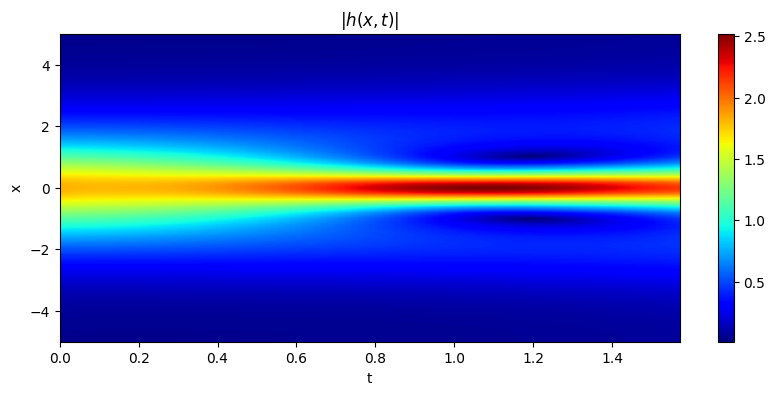

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.imshow(
    H,
    extent=[tmin, tmax, xmin, xmax],
    origin="lower",
    aspect="auto",
    cmap="jet"
)

plt.xlabel("t")
plt.ylabel("x")
plt.title(r"$|h(x,t)|$")
plt.colorbar()

plt.show()

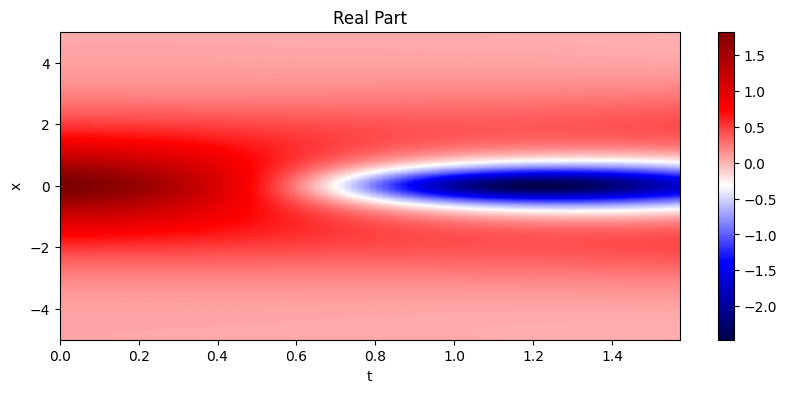

In [74]:
U = u_pred.reshape(Nx, Nt).cpu().numpy()

plt.figure(figsize=(10,4))
plt.imshow(
    U,
    extent=[tmin, tmax, xmin, xmax],
    origin="lower",
    aspect="auto",
    cmap="seismic"
)
plt.colorbar()
plt.title("Real Part")
plt.xlabel("t")
plt.ylabel("x")
plt.show()

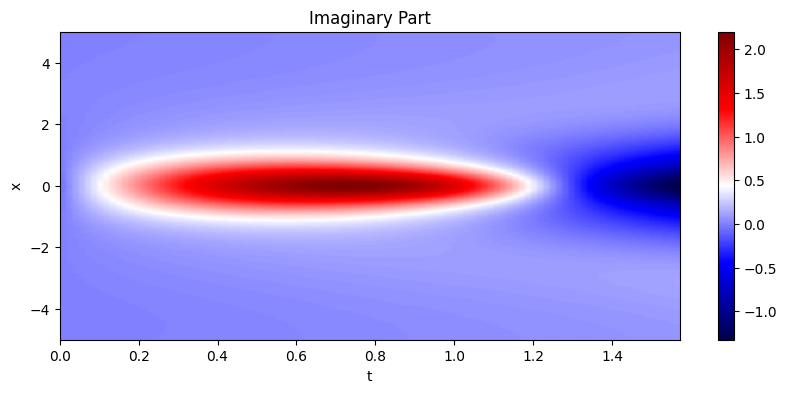

In [75]:
V = v_pred.reshape(Nx, Nt).cpu().numpy()

plt.figure(figsize=(10,4))
plt.imshow(
    V,
    extent=[tmin, tmax, xmin, xmax],
    origin="lower",
    aspect="auto",
    cmap="seismic"
)
plt.colorbar()
plt.title("Imaginary Part")
plt.xlabel("t")
plt.ylabel("x")
plt.show()